# 🧠 NLP in Action: Resume Mining & Opinion Mining

### 🎯 What You'll Build Today
- A **resume parser** that extracts name, skills, education, and experience
- A **job-resume matcher** that scores how well a candidate fits a role
- A **sentiment analyser** for product reviews
- An **aspect-based opinion extractor** for phone reviews- A **topic modeler** that discovers hidden themes in job postings and reviews

---
## ⚙️ Section 0 — Setup

Run this cell once. It installs everything needed for the session.

In [30]:
# Install all required libraries
!pip install spacy vaderSentiment textblob scikit-learn transformers torch --quiet
!python -m spacy download en_core_web_sm --quiet

print("✅ All libraries installed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 44.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ All libraries installed!


In [31]:
# Core imports — run this before anything else
import spacy
import re
import json
from collections import Counter

import warnings
warnings.filterwarnings('ignore')

nlp = spacy.load("en_core_web_sm")
print("✅ spaCy model loaded:", nlp.meta['name'])

✅ spaCy model loaded: core_web_sm


In [89]:
import warnings
warnings.filterwarnings('ignore')

---
# 📄 PART 1: Resume Mining

> **Resume mining** is the process of automatically extracting structured information — skills, education, experience — from the *unstructured* text of a resume.

**Why does it matter?**  
A recruiter at a large company might receive 500+ resumes for one job posting. Manually reading each one is impossible. NLP automates the screening.

**NLP Tasks Involved:**
1. Named Entity Recognition (NER)
2. Information Extraction
3. Text Classification
4. Keyword Matching / Ranking

---
## 1.1 — Our Sample Resume

We'll work with this realistic resume throughout Part 1.

In [32]:
SAMPLE_RESUME = """
Aditya Sharma
Email: aditya.sharma@email.com | Phone: +91-9876543210
LinkedIn: linkedin.com/in/adityasharma | GitHub: github.com/adityasharma
Location: Bangalore, India

OBJECTIVE
Motivated computer science graduate with hands-on experience in machine learning,
data analysis, and software development. Seeking a Data Scientist role at a
product-based company.

EDUCATION
B.Tech in Computer Science Engineering
Indian Institute of Technology, Bombay | 2019 – 2023 | CGPA: 8.7/10

XII (CBSE): 94.2% | St. Xavier's College, Mumbai | 2019

EXPERIENCE
Data Science Intern | Flipkart, Bangalore | June 2022 – August 2022
- Built a recommendation engine using collaborative filtering (Python, Pandas, Scikit-learn)
- Reduced data preprocessing time by 40% using automated ETL pipelines
- Presented findings to a team of 15 engineers and product managers

Machine Learning Intern | TCS Research, Pune | December 2021 – February 2022
- Developed an NLP model for customer ticket classification with 89% accuracy
- Used BERT fine-tuning on a dataset of 50,000 support tickets

SKILLS
Programming: Python, SQL, Java, R
ML/AI: TensorFlow, PyTorch, Scikit-learn, Keras, Hugging Face
Data Tools: Pandas, NumPy, Matplotlib, Seaborn, Power BI
Cloud: AWS (EC2, S3), Google Cloud Platform
Other: Git, Docker, REST APIs, Agile

PROJECTS
Fake News Detector | Python, BERT, Streamlit
- Fine-tuned BERT on 10,000 news articles; achieved 92% F1 score
- Deployed as a web app using Streamlit

Stock Price Predictor | Python, LSTM, Plotly
- Predicted NSE stock prices using LSTM with 15-day lookback window

CERTIFICATIONS
- Deep Learning Specialization — Coursera (Andrew Ng), 2022
- AWS Certified Cloud Practitioner, 2023

ACHIEVEMENTS
- Winner, Smart India Hackathon 2022 (team of 6)
- Ranked 312 in Google Kickstart Round C, 2022
"""

print("Resume loaded. Length:", len(SAMPLE_RESUME), "characters")
print(SAMPLE_RESUME[:300], "...")

Resume loaded. Length: 1811 characters

Aditya Sharma
Email: aditya.sharma@email.com | Phone: +91-9876543210
LinkedIn: linkedin.com/in/adityasharma | GitHub: github.com/adityasharma
Location: Bangalore, India

OBJECTIVE
Motivated computer science graduate with hands-on experience in machine learning,
data analysis, and software developme ...


---
## 1.2 — Named Entity Recognition (NER)

> **NER** identifies and classifies words/phrases into categories like PERSON, ORG, DATE, GPE (location).

**Think of NER as a highlighter** — it reads through the resume and highlights "John Smith" as a person, "Google" as an organization, "July 2022" as a date.

spaCy gives us NER out of the box. Let's see what it finds.

In [33]:
# Run spaCy NER on our resume
doc = nlp(SAMPLE_RESUME)

# Collect entities by type
entities_by_type = {}
for ent in doc.ents:
    if ent.label_ not in entities_by_type:
        entities_by_type[ent.label_] = []
    entities_by_type[ent.label_].append(ent.text.strip())

# Display results
print("📌 Entities found by spaCy:\n")
for label, items in entities_by_type.items():
    unique_items = list(dict.fromkeys(items))  # deduplicate
    print(f"  [{label}]: {unique_items}")

📌 Entities found by spaCy:

  [PERSON]: ['Aditya Sharma\nEmail', 'Bangalore', 'Pandas', 'Java', 'Keras', 'Matplotlib', 'Cloud Platform', 'Docker', 'Streamlit', 'Coursera', 'Andrew Ng', 'Cloud Practitioner']
  [GPE]: ['India', 'Bombay', 'Mumbai', 'NumPy']
  [ORG]: ['Data Scientist', 'B.Tech', 'Indian Institute of Technology', 'CBSE', "St. Xavier's College", 'TCS Research', 'NLP', 'BERT', 'SQL', 'ML/AI:', 'PyTorch', 'Seaborn', 'S3', 'Agile\n\nPROJECTS\nFake News Detector | Python', 'CERTIFICATIONS', 'Smart India', 'Google Kickstart Round C']
  [DATE]: ['2019', 'June 2022', 'August 2022', 'Pune | December 2021', 'February 2022', '15-day', '2023', '2022']
  [MONEY]: ['8.7/10\n\nXII']
  [PERCENT]: ['94.2%', '40%', '89%', '92%']
  [CARDINAL]: ['15', '50,000', '10,000', '2022', '6', '312']


In [34]:
# 🔍 Visualize NER inline (works best in Jupyter)
from spacy import displacy

# Use a shorter snippet so it renders clearly
snippet = """
Aditya Sharma worked as a Data Science Intern at Flipkart, Bangalore
from June 2022 to August 2022. He studied at IIT Bombay and graduated in 2023.
"""
doc_snippet = nlp(snippet)
displacy.render(doc_snippet, style="ent", jupyter=True)

### 🤔 Observation
spaCy's general model doesn't know about resume-specific entities like **skills** or **certifications**. In production, you'd fine-tune a custom NER model for those. We'll simulate that with rule-based extraction next.

---
## 1.3 — Information Extraction: Skills, Education & Experience

Real resume parsers combine NER with **pattern matching** and **section detection**.

In [35]:
# ─────────────────────────────────────────────
# STEP 1: Extract candidate name
# Heuristic: the first PERSON entity is usually the name
# ─────────────────────────────────────────────

def extract_name(text):
    doc = nlp(text)
    for ent in doc.ents:
        if ent.label_ == "PERSON":
            return ent.text.strip()
    # Fallback: first non-empty line
    for line in text.strip().split('\n'):
        if line.strip():
            return line.strip()
    return "Unknown"

name = extract_name(SAMPLE_RESUME)
print("👤 Candidate Name:", name)

👤 Candidate Name: Aditya Sharma
Email


In [36]:
# ─────────────────────────────────────────────
# STEP 2: Extract contact info using regex
# ─────────────────────────────────────────────

def extract_contact(text):
    email = re.findall(r'[\w.+-]+@[\w-]+\.[\w.-]+', text)
    phone = re.findall(r'[\+]?[\d][\d\s\-]{8,}[\d]', text)
    linkedin = re.findall(r'linkedin\.com/in/[\w-]+', text)
    github = re.findall(r'github\.com/[\w-]+', text)
    return {
        "email": email[0] if email else None,
        "phone": phone[0].strip() if phone else None,
        "linkedin": linkedin[0] if linkedin else None,
        "github": github[0] if github else None,
    }

contact = extract_contact(SAMPLE_RESUME)
print("📞 Contact Info:")
for k, v in contact.items():
    print(f"   {k}: {v}")

📞 Contact Info:
   email: aditya.sharma@email.com
   phone: +91-9876543210
   linkedin: linkedin.com/in/adityasharma
   github: github.com/adityasharma


In [37]:
# ─────────────────────────────────────────────
# STEP 3: Extract skills using a keyword vocabulary
# (In production: use a curated taxonomy like ESCO or O*NET)
# ─────────────────────────────────────────────

SKILL_VOCAB = {
    "Programming Languages": ["python", "java", "sql", "r", "c++", "javascript", "scala"],
    "ML/AI Frameworks":      ["tensorflow", "pytorch", "scikit-learn", "keras", "hugging face",
                               "bert", "lstm", "xgboost", "lightgbm"],
    "Data Tools":            ["pandas", "numpy", "matplotlib", "seaborn", "power bi",
                               "tableau", "spark", "hadoop"],
    "Cloud/DevOps":          ["aws", "gcp", "azure", "docker", "kubernetes", "git"],
    "NLP":                   ["nltk", "spacy", "transformers", "bert", "gpt", "ner",
                               "sentiment analysis", "text classification"],
}

def extract_skills(text, vocab):
    text_lower = text.lower()
    found = {}
    for category, skills in vocab.items():
        matched = [s for s in skills if s in text_lower]
        if matched:
            found[category] = matched
    return found

skills = extract_skills(SAMPLE_RESUME, SKILL_VOCAB)
print("🛠️ Skills Extracted:\n")
for cat, s in skills.items():
    print(f"   {cat}: {s}")

🛠️ Skills Extracted:

   Programming Languages: ['python', 'java', 'sql', 'r']
   ML/AI Frameworks: ['tensorflow', 'pytorch', 'scikit-learn', 'keras', 'hugging face', 'bert', 'lstm']
   Data Tools: ['pandas', 'numpy', 'matplotlib', 'seaborn', 'power bi']
   Cloud/DevOps: ['aws', 'docker', 'git']
   NLP: ['bert', 'ner']


In [38]:
# ─────────────────────────────────────────────
# STEP 4: Extract education section
# Strategy: locate the EDUCATION section header → parse until next section
# ─────────────────────────────────────────────

def extract_section(text, start_keyword, end_keywords):
    """Extract text between a section header and the next section."""
    lines = text.split('\n')
    in_section = False
    section_lines = []
    for line in lines:
        if start_keyword.lower() in line.lower():
            in_section = True
            continue
        if in_section:
            if any(kw.lower() in line.lower() for kw in end_keywords):
                break
            if line.strip():
                section_lines.append(line.strip())
    return section_lines

SECTION_HEADERS = ["OBJECTIVE", "EDUCATION", "EXPERIENCE", "SKILLS",
                   "PROJECTS", "CERTIFICATIONS", "ACHIEVEMENTS"]

education_lines = extract_section(SAMPLE_RESUME, "EDUCATION", SECTION_HEADERS)
experience_lines = extract_section(SAMPLE_RESUME, "EXPERIENCE", SECTION_HEADERS)

print("🎓 Education Section:")
for line in education_lines:
    print("  ", line)

print("\n💼 Experience Section:")
for line in experience_lines:
    print("  ", line)

🎓 Education Section:
   B.Tech in Computer Science Engineering
   Indian Institute of Technology, Bombay | 2019 – 2023 | CGPA: 8.7/10
   XII (CBSE): 94.2% | St. Xavier's College, Mumbai | 2019

💼 Experience Section:
   data analysis, and software development. Seeking a Data Scientist role at a
   product-based company.


In [39]:
# ─────────────────────────────────────────────
# STEP 5: Extract years of experience from dates
# ─────────────────────────────────────────────

def estimate_experience_years(text):
    """Find year ranges like '2021 – 2022' and sum months."""
    # Pattern: Month Year – Month Year  OR  Year – Year
    pattern = r'(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)[a-z]*\s+(\d{4})\s*[–\-]\s*(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)[a-z]*\s+(\d{4})'
    matches = re.findall(pattern, text, re.IGNORECASE)

    month_map = {"jan":1,"feb":2,"mar":3,"apr":4,"may":5,"jun":6,
                 "jul":7,"aug":8,"sep":9,"oct":10,"nov":11,"dec":12}
    total_months = 0
    for m in matches:
        start_month = month_map[m[0][:3].lower()]
        start_year  = int(m[1])
        end_month   = month_map[m[2][:3].lower()]
        end_year    = int(m[3])
        total_months += (end_year - start_year) * 12 + (end_month - start_month)

    return round(total_months / 12, 1), total_months

years, months = estimate_experience_years(SAMPLE_RESUME)
print(f"⏱️ Estimated internship/work experience: {months} months ({years} years)")

⏱️ Estimated internship/work experience: 4 months (0.3 years)


In [40]:
# ─────────────────────────────────────────────
# 📦 Putting it all together: Full Resume Parser
# ─────────────────────────────────────────────

def parse_resume(text):
    return {
        "name": extract_name(text),
        "contact": extract_contact(text),
        "skills": extract_skills(text, SKILL_VOCAB),
        "education": extract_section(text, "EDUCATION", SECTION_HEADERS),
        "experience_months": estimate_experience_years(text)[1],
        "certifications": extract_section(text, "CERTIFICATIONS", SECTION_HEADERS),
    }

parsed = parse_resume(SAMPLE_RESUME)

print("=" * 55)
print("         📋 PARSED RESUME PROFILE")
print("=" * 55)
print(f"Name              : {parsed['name']}")
print(f"Email             : {parsed['contact']['email']}")
print(f"Phone             : {parsed['contact']['phone']}")
print(f"LinkedIn          : {parsed['contact']['linkedin']}")
print(f"Experience (months): {parsed['experience_months']}")
print(f"\n🛠️ Skills:")
for cat, s in parsed['skills'].items():
    print(f"   {cat}: {', '.join(s)}")
print(f"\n🎓 Education:")
for line in parsed['education']:
    print(f"   {line}")
print(f"\n📜 Certifications:")
for line in parsed['certifications']:
    print(f"   {line}")

         📋 PARSED RESUME PROFILE
Name              : Aditya Sharma
Email
Email             : aditya.sharma@email.com
Phone             : +91-9876543210
LinkedIn          : linkedin.com/in/adityasharma
Experience (months): 4

🛠️ Skills:
   Programming Languages: python, java, sql, r
   ML/AI Frameworks: tensorflow, pytorch, scikit-learn, keras, hugging face, bert, lstm
   Data Tools: pandas, numpy, matplotlib, seaborn, power bi
   Cloud/DevOps: aws, docker, git
   NLP: bert, ner

🎓 Education:
   B.Tech in Computer Science Engineering
   Indian Institute of Technology, Bombay | 2019 – 2023 | CGPA: 8.7/10
   XII (CBSE): 94.2% | St. Xavier's College, Mumbai | 2019

📜 Certifications:
   - Deep Learning Specialization — Coursera (Andrew Ng), 2022
   - AWS Certified Cloud Practitioner, 2023


---
## 1.4 — Text Classification: Which Job Domain?

> **Text Classification** assigns a label to the entire resume — is this candidate a Data Scientist, a Frontend Developer, a DevOps Engineer?

We'll use **TF-IDF + Cosine Similarity** to classify against domain profiles.

In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Domain profiles: keywords that define each domain
DOMAIN_PROFILES = {
    "Data Science / ML": """
        machine learning deep learning neural network tensorflow pytorch scikit-learn
        data science pandas numpy matplotlib statistics regression classification
        NLP computer vision feature engineering model deployment
    """,
    "Web Development": """
        html css javascript react angular nodejs express mongodb mysql
        rest api frontend backend fullstack django flask web development
    """,
    "DevOps / Cloud": """
        docker kubernetes jenkins AWS azure GCP CI/CD terraform ansible
        linux bash scripting cloud infrastructure deployment monitoring
    """,
    "Data Engineering": """
        spark hadoop kafka airflow ETL data pipeline data warehouse
        SQL BigQuery Redshift Snowflake dbt data modeling streaming
    """,
    "Cybersecurity": """
        penetration testing vulnerability OWASP firewall encryption
        network security SIEM ethical hacking incident response compliance
    """,
}

# Vectorize everything together
corpus = list(DOMAIN_PROFILES.values()) + [SAMPLE_RESUME]
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(corpus)

# Resume is the last document; compute similarity to each domain
resume_vec = tfidf_matrix[-1]
domain_vecs = tfidf_matrix[:-1]
similarities = cosine_similarity(resume_vec, domain_vecs)[0]

print("🏷️ Domain Classification (higher = stronger match):\n")
domain_names = list(DOMAIN_PROFILES.keys())
for name, score in sorted(zip(domain_names, similarities), key=lambda x: -x[1]):
    bar = "█" * int(score * 40)
    print(f"  {name:<25} {score:.3f}  {bar}")

best = domain_names[np.argmax(similarities)]
print(f"\n✅ Predicted Domain: {best}")

🏷️ Domain Classification (higher = stronger match):

  Data Science / ML         0.256  ██████████
  Data Engineering          0.108  ████
  DevOps / Cloud            0.054  ██
  Web Development           0.026  █
  Cybersecurity             0.000  

✅ Predicted Domain: Data Science / ML


---
## 1.5 — Keyword Matching: Resume vs Job Description

> Real ATS systems (Applicant Tracking Systems) **score** each resume against a job description.  
> A low score means the resume gets **filtered out before a human ever sees it**.

We'll build a simple but effective **JD-Resume Matcher**.

In [42]:
JOB_DESCRIPTION = """
We are looking for a Data Scientist to join our Analytics team.

Required Skills:
- 1+ years of experience in machine learning or data science
- Strong proficiency in Python and SQL
- Experience with Scikit-learn, TensorFlow, or PyTorch
- Familiarity with NLP techniques (text classification, named entity recognition)
- Knowledge of Pandas, NumPy, and data visualization tools (Matplotlib, Seaborn)
- Experience with cloud platforms (AWS or GCP preferred)
- Ability to communicate findings to non-technical stakeholders

Good to Have:
- Experience with Hugging Face transformers
- Exposure to Docker and Git
- Knowledge of Power BI or Tableau
"""

# ─── Approach 1: Simple keyword overlap ───
def tokenize(text):
    """Lowercase and extract meaningful words."""
    words = re.findall(r'\b[a-zA-Z][a-zA-Z0-9\+\.]{1,}\b', text.lower())
    stop_words = {'and', 'or', 'the', 'of', 'to', 'in', 'for', 'with',
                  'is', 'are', 'we', 'a', 'an', 'our', 'you', 'your', 'be'}
    return set(words) - stop_words

jd_keywords = tokenize(JOB_DESCRIPTION)
resume_keywords = tokenize(SAMPLE_RESUME)

matched   = jd_keywords & resume_keywords
missing   = jd_keywords - resume_keywords
overlap_score = len(matched) / len(jd_keywords) * 100

print("📊 Keyword Match Analysis")
print(f"  JD Keywords      : {len(jd_keywords)}")
print(f"  Resume Keywords  : {len(resume_keywords)}")
print(f"  Matched Keywords : {len(matched)}")
print(f"  Match Score      : {overlap_score:.1f}%")
print(f"\n✅ Matched: {sorted(matched)[:15]} ...")
print(f"\n❌ Missing from Resume: {sorted(missing)[:15]} ...")

📊 Keyword Match Analysis
  JD Keywords      : 58
  Resume Keywords  : 163
  Matched Keywords : 30
  Match Score      : 51.7%

✅ Matched: ['aws', 'bi', 'classification', 'cloud', 'data', 'docker', 'experience', 'face', 'findings', 'git', 'hugging', 'learn', 'learning', 'machine', 'matplotlib'] ...

❌ Missing from Resume: ['ability', 'analytics', 'communicate', 'entity', 'exposure', 'familiarity', 'gcp', 'good', 'have', 'join', 'knowledge', 'looking', 'named', 'non', 'platforms'] ...


In [43]:
# ─── Approach 2: TF-IDF Cosine Similarity (more sophisticated) ───

vectorizer2 = TfidfVectorizer(stop_words='english', ngram_range=(1, 2))
tfidf2 = vectorizer2.fit_transform([JOB_DESCRIPTION, SAMPLE_RESUME])
cosine_score = cosine_similarity(tfidf2[0], tfidf2[1])[0][0]

print(f"\n🤖 TF-IDF Cosine Similarity Score: {cosine_score:.3f}")
print(f"   (Range: 0 = no match, 1 = identical)")

if cosine_score > 0.25:
    print("\n🟢 Verdict: Strong match — likely to pass ATS screening")
elif cosine_score > 0.1:
    print("\n🟡 Verdict: Moderate match — consider adding missing keywords")
else:
    print("\n🔴 Verdict: Weak match — resume needs significant tailoring")


🤖 TF-IDF Cosine Similarity Score: 0.162
   (Range: 0 = no match, 1 = identical)

🟡 Verdict: Moderate match — consider adding missing keywords


### 💡 Key Insight
This is why career advisors say *"tailor your resume for every job"* — ATS systems literally score you on keyword overlap with the JD.

---
### ✏️ Exercise 1 (5 min)
Try writing a short resume for yourself (3–5 lines each for skills, education, experience) and run it through the `parse_resume()` and matching functions. What score do you get?

In [44]:
# YOUR RESUME HERE — fill in your details!
MY_RESUME = """
Your Name

EDUCATION
B.Tech Computer Science | Your College | 2021–2025

SKILLS
Python, SQL, Machine Learning, Pandas

EXPERIENCE
Intern | Some Company | June 2024 – August 2024
- Did something interesting with data
"""

# Uncomment and run to test your resume
# my_parsed = parse_resume(MY_RESUME)
# print(json.dumps({k: v for k, v in my_parsed.items() if k != 'education'}, indent=2))

# tfidf3 = vectorizer2.transform([JOB_DESCRIPTION, MY_RESUME])
# my_score = cosine_similarity(tfidf3[0], tfidf3[1])[0][0]
# print(f"Your JD Match Score: {my_score:.3f}")

---
# 🗣️ PART 2: Opinion Mining (Sentiment Analysis)

> **Opinion mining** extracts *subjective* information from text — emotions, opinions, and attitudes.

**Why does it matter?**  
Amazon processes millions of reviews. Twitter generates 500M+ tweets/day. No human team can read all of it. NLP reads it for us.

**Three levels of analysis:**
1. **Document-level** — Is this review overall positive or negative?
2. **Sentence-level** — Which sentences are negative?
3. **Aspect-level** — Positive about camera, negative about battery?

---
## 2.1 — Rule-Based Sentiment: VADER

> **VADER** (Valence Aware Dictionary and sEntiment Reasoner) uses a hand-crafted lexicon. No training needed. Works well on social media text and short reviews.

In [45]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

vader = SentimentIntensityAnalyzer()

# Sample texts to analyze
sample_texts = [
    "This phone is absolutely amazing! Best purchase I've ever made. 🔥",
    "Terrible product. Stopped working after 2 days. Complete waste of money.",
    "Battery life is okay. Camera is decent but nothing special.",
    "The delivery was SUPER fast but the packaging was a bit damaged.",
    "Not bad, not great. It does what it says on the box.",
    "मुझे यह उत्पाद बहुत पसंद आया!",  # Hindi — VADER won't handle this well
]

print("📊 VADER Sentiment Scores\n")
print(f"{'Text':<55} {'Pos':>5} {'Neu':>5} {'Neg':>5} {'Label':>10}")
print("-" * 90)

for text in sample_texts:
    scores = vader.polarity_scores(text)
    compound = scores['compound']
    label = "POSITIVE" if compound >= 0.05 else ("NEGATIVE" if compound <= -0.05 else "NEUTRAL")
    short_text = text[:52] + "..." if len(text) > 52 else text
    print(f"{short_text:<55} {scores['pos']:>5.2f} {scores['neu']:>5.2f} {scores['neg']:>5.2f} {label:>10}")

📊 VADER Sentiment Scores

Text                                                      Pos   Neu   Neg      Label
------------------------------------------------------------------------------------------
This phone is absolutely amazing! Best purchase I've...  0.46  0.41  0.12   POSITIVE
Terrible product. Stopped working after 2 days. Comp...  0.00  0.51  0.49   NEGATIVE
Battery life is okay. Camera is decent but nothing s...  0.12  0.65  0.23   NEGATIVE
The delivery was SUPER fast but the packaging was a ...  0.17  0.60  0.23   NEGATIVE
Not bad, not great. It does what it says on the box.     0.36  0.64  0.00   POSITIVE
मुझे यह उत्पाद बहुत पसंद आया!                            0.00  1.00  0.00    NEUTRAL


In [46]:
# 🔬 Deep dive: What makes VADER tick?
# VADER handles: ALL CAPS, punctuation (!), emojis, and degree modifiers

test_cases = [
    ("good",          "base word"),
    ("GOOD",          "ALL CAPS boosts intensity"),
    ("good!!!",       "punctuation boosts intensity"),
    ("very good",     "degree modifier"),
    ("not good",      "negation"),
    ("kind of good", "downgrade modifier"),
    ("good 😊",       "emoji"),
]

print("🔍 VADER Feature Demonstration\n")
for text, description in test_cases:
    score = vader.polarity_scores(text)['compound']
    print(f"  '{text}'  [{description}]  → compound: {score:+.3f}")

🔍 VADER Feature Demonstration

  'good'  [base word]  → compound: +0.440
  'GOOD'  [ALL CAPS boosts intensity]  → compound: +0.440
  'good!!!'  [punctuation boosts intensity]  → compound: +0.583
  'very good'  [degree modifier]  → compound: +0.493
  'not good'  [negation]  → compound: -0.341
  'kind of good'  [downgrade modifier]  → compound: +0.440
  'good 😊'  [emoji]  → compound: +0.836


---
## 2.2 — ML-Based Sentiment: TextBlob

> **TextBlob** uses a Naive Bayes classifier trained on a movie reviews corpus. It returns **polarity** (−1 to +1) and **subjectivity** (0=factual, 1=very opinionated).

In [47]:
from textblob import TextBlob

reviews = [
    "The OnePlus 12 is an incredible phone. The display is stunning and performance is top-notch.",
    "Zomato delivered cold food again. The app is convenient but quality control is terrible.",
    "Swiggy Instamart is a game changer! Got groceries in 10 minutes. Highly recommended.",
    "My Ola cab got cancelled three times. The driver rating system is broken.",
    "IRCTC website crashes every time I try to book. This is a technical disaster.",
]

print("📊 TextBlob Sentiment Analysis\n")
print(f"{'Review':<60} {'Polarity':>9} {'Subjectivity':>13} {'Label':>10}")
print("-" * 100)

for review in reviews:
    blob = TextBlob(review)
    pol = blob.sentiment.polarity
    sub = blob.sentiment.subjectivity
    label = "😊 POS" if pol > 0.1 else ("😠 NEG" if pol < -0.1 else "😐 NEU")
    short = review[:57] + "..." if len(review) > 57 else review
    print(f"{short:<60} {pol:>+9.3f} {sub:>13.3f} {label:>10}")

📊 TextBlob Sentiment Analysis

Review                                                        Polarity  Subjectivity      Label
----------------------------------------------------------------------------------------------------
The OnePlus 12 is an incredible phone. The display is stu...    +0.800         0.967      😊 POS
Zomato delivered cold food again. The app is convenient b...    -0.800         1.000      😠 NEG
Swiggy Instamart is a game changer! Got groceries in 10 m...    -0.170         0.470      😠 NEG
My Ola cab got cancelled three times. The driver rating s...    -0.400         0.400      😠 NEG
IRCTC website crashes every time I try to book. This is a...    +0.000         0.100      😐 NEU


In [48]:
# 🔍 Subjectivity matters!
# High polarity + low subjectivity = probably a fact stated positively
# High polarity + high subjectivity = a genuine opinion

comparisons = [
    "The iPhone 15 has a 48MP camera.",      # Fact — low subjectivity
    "The iPhone 15 camera is absolutely gorgeous!",  # Opinion — high subjectivity
    "This movie has a runtime of 2 hours.",          # Fact
    "This movie is a masterpiece — I loved every minute!",  # Opinion
]

print("📐 Polarity vs. Subjectivity\n")
for text in comparisons:
    blob = TextBlob(text)
    pol = blob.sentiment.polarity
    sub = blob.sentiment.subjectivity
    nature = "📰 FACT-LIKE" if sub < 0.4 else "💬 OPINION"
    print(f"  '{text}'")
    print(f"   → Polarity: {pol:+.2f}, Subjectivity: {sub:.2f}  [{nature}]\n")

📐 Polarity vs. Subjectivity

  'The iPhone 15 has a 48MP camera.'
   → Polarity: +0.00, Subjectivity: 0.00  [📰 FACT-LIKE]

  'The iPhone 15 camera is absolutely gorgeous!'
   → Polarity: +0.88, Subjectivity: 0.90  [💬 OPINION]

  'This movie has a runtime of 2 hours.'
   → Polarity: +0.00, Subjectivity: 0.00  [📰 FACT-LIKE]

  'This movie is a masterpiece — I loved every minute!'
   → Polarity: +0.88, Subjectivity: 0.80  [💬 OPINION]



---
## 2.3 — Sentence-Level Sentiment

A single review can contain **mixed** sentiments. Sentence-level analysis reveals where the positives and negatives are.

In [49]:
# Download all necessary corpora for TextBlob
!python -m textblob.download_corpora

print("✅ TextBlob corpora downloaded. Please run the cell above again.")

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Package conll2000 is already up-to-date!
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
Finished.
✅ TextBlob corpora downloaded. Please run the cell above again.


In [50]:
import nltk
nltk.download('punkt')

mixed_review = """
I've been using this laptop for 3 months now. The build quality is excellent and the
display is one of the best I've seen. The keyboard is comfortable for long coding sessions.
However, the battery life is a huge disappointment. It barely lasts 4 hours on a full
charge, which is unacceptable for this price range. The fan noise is also annoyingly loud
under any load. Customer support was responsive and resolved my issue within 24 hours,
which was a pleasant surprise. Overall, a mixed bag — great hardware but poor power management.
"""

# Analyze sentence by sentence
blob = TextBlob(mixed_review)

print("🔍 Sentence-Level Sentiment Analysis\n")
positive_count = negative_count = neutral_count = 0

for sentence in blob.sentences:
    pol = sentence.sentiment.polarity
    if pol > 0.1:
        emoji = "✅"
        label = "POSITIVE"
        positive_count += 1
    elif pol < -0.1:
        emoji = "❌"
        label = "NEGATIVE"
        negative_count += 1
    else:
        emoji = "⬜"
        label = "NEUTRAL "
        neutral_count += 1
    print(f"  {emoji} [{label} {pol:+.2f}] {str(sentence).strip()}")

print(f"\n📊 Summary: {positive_count} positive, {negative_count} negative, {neutral_count} neutral sentences")

🔍 Sentence-Level Sentiment Analysis

  ⬜ [NEUTRAL  +0.00] I've been using this laptop for 3 months now.
  ✅ [POSITIVE +1.00] The build quality is excellent and the
display is one of the best I've seen.
  ✅ [POSITIVE +0.18] The keyboard is comfortable for long coding sessions.
  ⬜ [NEUTRAL  -0.10] However, the battery life is a huge disappointment.
  ✅ [POSITIVE +0.20] It barely lasts 4 hours on a full
charge, which is unacceptable for this price range.
  ⬜ [NEUTRAL  +0.10] The fan noise is also annoyingly loud
under any load.
  ✅ [POSITIVE +0.73] Customer support was responsive and resolved my issue within 24 hours,
which was a pleasant surprise.
  ⬜ [NEUTRAL  +0.10] Overall, a mixed bag — great hardware but poor power management.

📊 Summary: 4 positive, 0 negative, 4 neutral sentences


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


---
## 2.4 — Aspect-Based Sentiment Analysis (ABSA)

> **ABSA** goes deeper: it identifies *which feature* of a product the opinion is about.

**Example:**  
*"The camera is stunning but the battery is terrible"*  
→ camera: POSITIVE | battery: NEGATIVE

We'll build a lightweight ABSA system using dependency parsing.

In [51]:
# Define product aspects we care about
ASPECTS = {
    "battery":     ["battery", "charge", "charging", "battery life", "power"],
    "camera":      ["camera", "photo", "photos", "picture", "images", "lens", "selfie"],
    "display":     ["display", "screen", "resolution", "brightness", "amoled"],
    "performance": ["performance", "speed", "fast", "slow", "lag", "processor", "ram"],
    "design":      ["design", "build", "look", "feel", "lightweight", "premium"],
    "price":       ["price", "cost", "value", "expensive", "cheap", "worth"],
    "software":    ["software", "ui", "interface", "os", "android", "updates"],
}

phone_review = """
The Samsung Galaxy S24 is a beast of a phone. The display is absolutely gorgeous —
bright, vibrant, and smooth. The camera performance is outstanding, especially in low light.
Battery life is decent, easily lasting through a full day of heavy use.
However, the price is outrageously high for what you get. The software has too many
pre-installed apps and the UI feels bloated. Build quality is premium and it feels
great in the hand. Performance is snappy with zero lag in daily use.
"""

def aspect_sentiment(text, aspects, analyzer):
    """Assign sentiment to each aspect found in the text."""
    results = {}
    sentences = [s.strip() for s in re.split(r'[.!?]', text) if s.strip()]

    for sentence in sentences:
        sentence_lower = sentence.lower()
        for aspect, keywords in aspects.items():
            if any(kw in sentence_lower for kw in keywords):
                scores = analyzer.polarity_scores(sentence)
                compound = scores['compound']
                label = "POSITIVE" if compound > 0.05 else ("NEGATIVE" if compound < -0.05 else "NEUTRAL")
                if aspect not in results:
                    results[aspect] = []
                results[aspect].append((compound, label, sentence.strip()))
    return results

aspect_results = aspect_sentiment(phone_review, ASPECTS, vader)

print("📱 Aspect-Based Sentiment Analysis: Samsung Galaxy S24\n")
print(f"{'Aspect':<14} {'Avg Score':>10}  {'Label':<10} Evidence")
print("-" * 90)

for aspect, mentions in sorted(aspect_results.items()):
    avg_score = sum(m[0] for m in mentions) / len(mentions)
    overall = "✅ POSITIVE" if avg_score > 0.05 else ("❌ NEGATIVE" if avg_score < -0.05 else "⬜ NEUTRAL")
    evidence = mentions[0][2][:55] + "..."
    print(f"  {aspect:<12} {avg_score:>+10.3f}  {overall:<14} '{evidence}'")

📱 Aspect-Based Sentiment Analysis: Samsung Galaxy S24

Aspect          Avg Score  Label      Evidence
------------------------------------------------------------------------------------------
  battery          +0.340  ✅ POSITIVE     'Battery life is decent, easily lasting through a full d...'
  camera           +0.386  ✅ POSITIVE     'The camera performance is outstanding, especially in lo...'
  design           +0.404  ✅ POSITIVE     'The software has too many
pre-installed apps and the UI...'
  display          +0.897  ✅ POSITIVE     'The display is absolutely gorgeous —
bright, vibrant, a...'
  performance      +0.023  ⬜ NEUTRAL      'The camera performance is outstanding, especially in lo...'
  price            -0.296  ❌ NEGATIVE     'However, the price is outrageously high for what you ge...'
  software         +0.404  ✅ POSITIVE     'The software has too many
pre-installed apps and the UI...'


---
## 2.5 — Transformer-Based Sentiment (State of the Art)

> **Transformers** (BERT, RoBERTa, DistilBERT) are the current gold standard.  
> They understand *context* — the word "sick" means something very different in "I'm sick" vs "That move was sick!"

In [52]:
from transformers import pipeline

print("⏳ Loading DistilBERT sentiment model...")
# This model is ~67MB — downloads once and caches
sentiment_pipe = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    truncation=True,
    max_length=512
)
print("✅ Model loaded!")

⏳ Loading DistilBERT sentiment model...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

✅ Model loaded!


In [53]:
# Test on tricky sentences that rule-based models often get wrong
tricky_texts = [
    "I was sick of my old phone, so I bought this one. Best decision ever!",  # 'sick' as frustration, not illness
    "This phone is not bad at all.",       # Double negative = positive
    "The camera is to die for!",           # Idiom = very positive
    "I couldn't be more disappointed.",   # Sophisticated negation
    "Surprisingly, the budget phone beats flagship models in most tests.",
    "It's okay, I guess. Nothing to write home about.",  # Muted/lukewarm
]

print("🤖 DistilBERT Sentiment Analysis\n")
print(f"{'Text':<60} {'Label':>10} {'Score':>8}")
print("-" * 85)

results = sentiment_pipe(tricky_texts)
for text, result in zip(tricky_texts, results):
    label = result['label']
    score = result['score']
    emoji = "😊" if label == "POSITIVE" else "😠"
    short = text[:57] + "..." if len(text) > 57 else text
    print(f"  {short:<60} {emoji} {label:>8}  {score:>.3f}")

🤖 DistilBERT Sentiment Analysis

Text                                                              Label    Score
-------------------------------------------------------------------------------------
  I was sick of my old phone, so I bought this one. Best de... 😊 POSITIVE  0.994
  This phone is not bad at all.                                😊 POSITIVE  0.999
  The camera is to die for!                                    😊 POSITIVE  0.999
  I couldn't be more disappointed.                             😠 NEGATIVE  0.631
  Surprisingly, the budget phone beats flagship models in m... 😊 POSITIVE  0.949
  It's okay, I guess. Nothing to write home about.             😠 NEGATIVE  0.725


In [54]:
# 📊 Compare VADER vs TextBlob vs DistilBERT on the same texts

comparison_texts = [
    "This is not a bad phone.",
    "The camera is to die for!",
    "Battery life could be better but overall a great device.",
    "I was sick and tired of my old phone — this one changed everything!",
]

print("⚖️ Model Comparison: VADER vs TextBlob vs DistilBERT\n")
print(f"{'Text':<50} {'VADER':>10} {'TextBlob':>10} {'BERT':>12}")
print("-" * 90)

bert_results = sentiment_pipe(comparison_texts)

for text, bert_res in zip(comparison_texts, bert_results):
    # VADER
    v = vader.polarity_scores(text)['compound']
    v_label = "POS" if v > 0.05 else ("NEG" if v < -0.05 else "NEU")

    # TextBlob
    tb = TextBlob(text).sentiment.polarity
    tb_label = "POS" if tb > 0.05 else ("NEG" if tb < -0.05 else "NEU")

    # BERT
    b_label = bert_res['label'][:3]

    agree = "✅" if v_label == tb_label == b_label else "⚠️"
    short = text[:47] + "..." if len(text) > 47 else text
    print(f"  {short:<50} {v_label:>10} {tb_label:>10} {b_label:>12}  {agree}")

⚖️ Model Comparison: VADER vs TextBlob vs DistilBERT

Text                                                    VADER   TextBlob         BERT
------------------------------------------------------------------------------------------
  This is not a bad phone.                                  POS        POS          POS  ✅
  The camera is to die for!                                 NEG        NEU          POS  ⚠️
  Battery life could be better but overall a grea...        POS        POS          POS  ✅
  I was sick and tired of my old phone — this one...        NEG        NEG          NEG  ✅


---
## 2.6 — Emotion Detection

> Beyond positive/negative, we can detect **specific emotions**: joy, anger, sadness, fear, surprise, disgust.

We'll use a pre-trained HuggingFace model fine-tuned for multi-label emotion classification.

In [55]:
print("⏳ Loading emotion detection model...")
emotion_pipe = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    return_all_scores=True,
    truncation=True
)
print("✅ Emotion model loaded!")

⏳ Loading emotion detection model...


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Emotion model loaded!


In [56]:
emotion_texts = [
    "I just got placed at Google! This is the best day of my life!",
    "My laptop crashed 2 hours before the deadline. I lost everything.",
    "The professor cancelled the exam again without any notice. This is ridiculous.",
    "I don't know what to do about the situation. I feel lost.",
    "The surprise party they threw was absolutely amazing!",
]

EMOTION_EMOJIS = {
    "joy": "😄", "sadness": "😢", "anger": "😡",
    "fear": "😨", "surprise": "😲", "disgust": "🤢", "neutral": "😐"
}

print("🎭 Emotion Detection\n")
for text in emotion_texts:
    # The pipeline outputs a list of lists of dicts: [[{'label': 'joy', 'score': ...}, ...]]
    # Or, in some cases, just a list of dicts: [{'label': 'joy', 'score': ...}, ...]
    # We need to ensure 'result' is a list of dicts for sorting.
    pipeline_output = emotion_pipe(text)
    if isinstance(pipeline_output[0], list):
        result = pipeline_output[0]
    else:
        result = pipeline_output

    # Sort by score, take top 3
    top_emotions = sorted(result, key=lambda x: x['score'], reverse=True)[:3]
    print(f"  📝 '{text[:75]}'")
    for e in top_emotions:
        label = e['label'].lower()
        emoji = EMOTION_EMOJIS.get(label, "❓")
        bar = "█" * int(e['score'] * 20)
        print(f"     {emoji} {label:<10} {e['score']:.3f}  {bar}")
    print()

🎭 Emotion Detection

  📝 'I just got placed at Google! This is the best day of my life!'
     😄 joy        0.694  █████████████

  📝 'My laptop crashed 2 hours before the deadline. I lost everything.'
     😢 sadness    0.798  ███████████████

  📝 'The professor cancelled the exam again without any notice. This is ridiculo'
     😡 anger      0.694  █████████████

  📝 'I don't know what to do about the situation. I feel lost.'
     😢 sadness    0.949  ██████████████████

  📝 'The surprise party they threw was absolutely amazing!'
     😲 surprise   0.609  ████████████



---
## 2.7 — Real-World Application: Review Dashboard

Let's build a mini analytics pipeline for an e-commerce product — simulating what Amazon/Flipkart actually does.

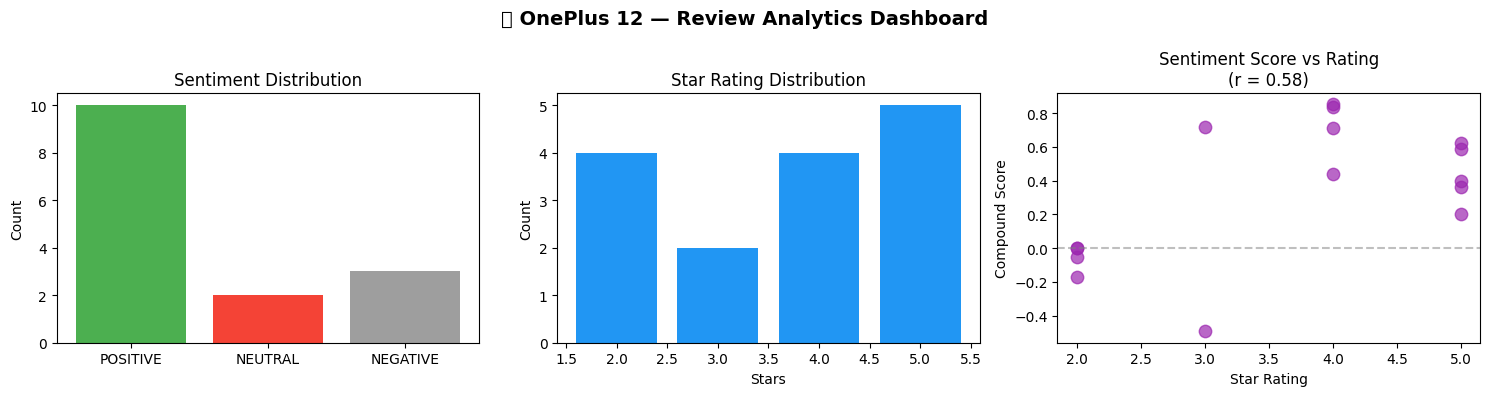


📈 Product Summary:
   Average Star Rating : 3.7/5
   Average Sentiment   : +0.335
   Correlation (r)     : 0.58
   Total Reviews       : 15


In [59]:
import matplotlib.pyplot as plt
import numpy as np

# Simulated product reviews (OnePlus 12 on Flipkart)
PRODUCT_REVIEWS = [
    ("Amazing performance, zero lag even with 20 apps open!", 5),
    ("Best camera phone under 65K. Night mode is insane.", 5),
    ("Battery drains fast. Barely lasts 6 hours with moderate use.", 2),
    ("Value for money. Display is gorgeous and bright outdoors.", 4),
    ("Heating issue is real. Gets hot during gaming sessions.", 2),
    ("Arrived on time, packaging was good. Phone is premium looking.", 4),
    ("OxygenOS is clean and smooth. No unnecessary bloatware!", 5),
    ("Disappointed with camera in bright daylight. Overexposed photos.", 2),
    ("Great build quality. Feels solid and premium in hand.", 4),
    ("Speaker sound is amazing. Dolby Atmos makes a real difference.", 5),
    ("The price is very high for features offered. Not worth it.", 2),
    ("Fast charging is a lifesaver. 100% in under 30 minutes!", 5),
    ("Screen protector not included at this price? Disappointing.", 3),
    ("Excellent for office work and multitasking. No complaints.", 4),
    ("Haptic feedback is too strong. Wish it could be turned off.", 3),
]

# Analyze all reviews
sentiments = []
for review, rating in PRODUCT_REVIEWS:
    scores = vader.polarity_scores(review)
    sentiments.append({
        "text": review,
        "rating": rating,
        "compound": scores['compound'],
        "pos": scores['pos'],
        "neg": scores['neg'],
        "label": "POSITIVE" if scores['compound'] > 0.05 else ("NEGATIVE" if scores['compound'] < -0.05 else "NEUTRAL")
    })

# ── Dashboard ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("📊 OnePlus 12 — Review Analytics Dashboard", fontsize=14, fontweight='bold')

# Chart 1: Sentiment Distribution
label_counts = Counter(s['label'] for s in sentiments)
colors = ['#4CAF50', '#F44336', '#9E9E9E']
axes[0].bar(label_counts.keys(), label_counts.values(), color=colors[:len(label_counts)])
axes[0].set_title("Sentiment Distribution")
axes[0].set_ylabel("Count")

# Chart 2: Star Rating Distribution
rating_counts = Counter(s['rating'] for s in sentiments)
axes[1].bar(rating_counts.keys(), rating_counts.values(), color='#2196F3')
axes[1].set_title("Star Rating Distribution")
axes[1].set_xlabel("Stars")
axes[1].set_ylabel("Count")

# Chart 3: Sentiment Score vs Star Rating
ratings = [s['rating'] for s in sentiments]
compounds = [s['compound'] for s in sentiments]
axes[2].scatter(ratings, compounds, alpha=0.7, color='#9C27B0', s=80)
axes[2].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[2].set_title("Sentiment Score vs Rating")
axes[2].set_xlabel("Star Rating")
axes[2].set_ylabel("Compound Score")

# Add correlation
correlation = np.corrcoef(ratings, compounds)[0, 1]
axes[2].set_title(f"Sentiment Score vs Rating\n(r = {correlation:.2f})")

plt.tight_layout()
plt.savefig('/content/review_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
avg_sentiment = np.mean([s['compound'] for s in sentiments])
avg_rating = np.mean([s['rating'] for s in sentiments])
print(f"\n📈 Product Summary:")
print(f"   Average Star Rating : {avg_rating:.1f}/5")
print(f"   Average Sentiment   : {avg_sentiment:+.3f}")
print(f"   Correlation (r)     : {correlation:.2f}")
print(f"   Total Reviews       : {len(sentiments)}")

In [60]:
# 🔍 Extract KEY PHRASES from positive & negative reviews (Opinion Summarization)

from sklearn.feature_extraction.text import TfidfVectorizer

positive_reviews = [s['text'] for s in sentiments if s['label'] == 'POSITIVE']
negative_reviews = [s['text'] for s in sentiments if s['label'] == 'NEGATIVE']

def top_keywords(texts, n=8):
    if not texts:
        return []
    vec = TfidfVectorizer(stop_words='english', ngram_range=(1,2), max_features=20)
    try:
        tfidf = vec.fit_transform(texts)
        scores = tfidf.toarray().sum(axis=0)
        keywords = sorted(zip(vec.get_feature_names_out(), scores), key=lambda x: -x[1])
        return [kw for kw, _ in keywords[:n]]
    except:
        return []

pos_keywords = top_keywords(positive_reviews)
neg_keywords = top_keywords(negative_reviews)

print("✅ What customers LOVE:")
print("  ", " | ".join(pos_keywords))

print("\n❌ What customers DISLIKE:")
print("  ", " | ".join(neg_keywords))

✅ What customers LOVE:
   premium | bloatware | phone | amazing | arrived | amazing dolby | atmos makes | 100

❌ What customers DISLIKE:
   price | disappointing | included | included price | features | features offered | high | high features


---
# 📰 PART 3: Topic Modeling

> **Topic modeling** is an *unsupervised* NLP technique that automatically discovers hidden themes (topics) in a large collection of documents — without anyone telling it what the themes are.

**The core question it answers:**  
*"I have 10,000 documents. What are they actually about?"*

**Real-world uses:**
- Discover what job skills are trending across thousands of job postings
- Find the main complaint themes across millions of support tickets
- Automatically tag news articles by topic
- Understand what topics a candidate's resume covers

**Three algorithms we'll cover:**

| Algorithm | Full Name | Intuition |
|-----------|-----------|----------|
| **LDA** | Latent Dirichlet Allocation | A document is a *mix* of topics; each topic is a *distribution* over words |
| **NMF** | Non-negative Matrix Factorization | Factorize a word-count matrix into topics × word weights |
| **BERTopic** | BERT + clustering | Use transformer embeddings → cluster → label topics |


---
## 3.1 — Intuition: How LDA Works

Imagine you're writing a resume. You decide:
- 60% of it will be about **machine learning**
- 30% about **cloud/infrastructure**
- 10% about **soft skills**

Each topic has its own vocabulary: ML topic uses words like *neural*, *training*, *accuracy*; Cloud topic uses *docker*, *deploy*, *kubernetes*.

**LDA reverses this process** — given the final document, it figures out the topic mix and the word distributions that most likely produced it.

```
Documents  ──→  [Word counts]  ──→  LDA  ──→  Topics (word distributions)
                                          ──→  Document-topic proportions
```

In [61]:
# Install additional libraries for Topic Modeling
!pip install pyLDAvis gensim --quiet
print("✅ Topic modeling libraries ready!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 69.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 32.1 MB/s eta 0:00:00
✅ Topic modeling libraries ready!


In [62]:
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("✅ Imports ready")

✅ Imports ready


---
## 3.2 — Dataset: Job Postings Corpus

We'll apply topic modeling to a corpus of job postings — simulating what LinkedIn/Naukri does to understand market skill trends.

In [63]:
# Realistic job posting corpus (25 postings across 5 domains)
JOB_POSTINGS = [
    # ── Data Science / ML ──
    "We need a Data Scientist proficient in Python, machine learning, scikit-learn, pandas, numpy. "
    "Experience with deep learning frameworks like TensorFlow or PyTorch is required. "
    "You will build predictive models, perform feature engineering, and present findings to stakeholders.",

    "Looking for a Machine Learning Engineer to build and deploy ML pipelines. Must know Python, "
    "Scikit-learn, XGBoost, model evaluation, and MLflow for experiment tracking. "
    "Experience with AWS SageMaker and Docker containers is a plus.",

    "AI Research Scientist role requiring deep expertise in transformer architectures, BERT, GPT, "
    "attention mechanisms, fine-tuning large language models, and NLP tasks such as text classification "
    "and named entity recognition. Publications in top AI conferences preferred.",

    "Data Analyst position: strong SQL, Excel, Power BI, Tableau. Analyse business KPIs, "
    "build dashboards, create reports for leadership. Python and pandas a bonus. "
    "Excellent communication and storytelling with data required.",

    "NLP Engineer needed with expertise in spaCy, NLTK, Hugging Face transformers, "
    "text preprocessing, tokenization, word embeddings, and deploying NLP APIs. "
    "Hands-on experience with sentiment analysis and information extraction preferred.",

    # ── Web Development ──
    "Full Stack Developer: React, Node.js, Express, MongoDB, REST APIs, HTML, CSS, JavaScript. "
    "You'll build responsive web applications, integrate third-party APIs, and "
    "collaborate with UI/UX designers to deliver smooth user experiences.",

    "Frontend Engineer with strong React, TypeScript, Redux, Webpack, and Jest experience. "
    "Build high-performance, accessible, and responsive user interfaces. "
    "Knowledge of Next.js and GraphQL is highly desirable.",

    "Backend Developer: Python Django or FastAPI, PostgreSQL, Redis, REST APIs, "
    "microservices architecture. Write clean, testable code, design database schemas, "
    "and implement authentication and authorization systems.",

    "Mobile App Developer (Android/iOS): React Native, Flutter, or native development. "
    "Firebase, RESTful APIs, push notifications, app store deployment. "
    "Strong understanding of mobile UX principles and offline-first architecture.",

    "UI/UX Developer with Figma, HTML, CSS, JavaScript, and animation libraries. "
    "Create wireframes, prototypes, and high-fidelity designs. "
    "Conduct user research and usability testing to iterate on designs.",

    # ── DevOps / Cloud ──
    "DevOps Engineer: AWS, Terraform, Ansible, Jenkins, CI/CD pipelines, Docker, Kubernetes. "
    "Automate infrastructure provisioning, manage deployment pipelines, "
    "and ensure high availability and scalability of production systems.",

    "Cloud Architect role on GCP and AWS. Expertise in Kubernetes, serverless architecture, "
    "IAM, VPC networking, and cost optimization. Design cloud-native solutions "
    "for enterprise clients across BFSI and e-commerce domains.",

    "Site Reliability Engineer (SRE): Prometheus, Grafana, PagerDuty, incident management, "
    "Linux system administration, bash scripting, and on-call rotations. "
    "Maintain SLAs, reduce toil, and build self-healing infrastructure.",

    "Platform Engineer: Helm charts, ArgoCD, GitOps, Kubernetes cluster management, "
    "service mesh (Istio), container security. Build internal developer platforms "
    "to improve developer productivity and deployment velocity.",

    "Cloud Security Engineer: IAM policies, encryption, compliance (SOC2, ISO27001), "
    "vulnerability scanning, SIEM, AWS Security Hub. Conduct threat modeling "
    "and penetration testing across cloud infrastructure.",

    # ── Data Engineering ──
    "Data Engineer: Apache Spark, Kafka, Airflow, dbt, Snowflake, BigQuery. "
    "Design and build scalable ETL pipelines, data warehouses, and real-time streaming systems. "
    "SQL and Python expertise essential.",

    "Analytics Engineer: dbt, Snowflake, Looker, SQL, Python, data modeling. "
    "Build clean, reliable data models that power business dashboards and self-serve analytics. "
    "Work closely with data scientists and business stakeholders.",

    "Big Data Engineer with Hadoop, HDFS, Hive, Pig, Spark Streaming experience. "
    "Optimize large-scale batch and streaming data processing jobs. "
    "Handle petabyte-scale datasets in a distributed computing environment.",

    "Real-time Data Engineer: Apache Flink, Kafka Streams, Redis, ClickHouse. "
    "Build sub-second latency data pipelines for fraud detection, "
    "recommendation engines, and operational dashboards.",

    "Database Administrator: PostgreSQL, MySQL, Oracle, query optimization, indexing, "
    "backup and recovery, replication, and performance tuning. "
    "Ensure data integrity, security, and availability of production databases.",

    # ── Cybersecurity ──
    "Cybersecurity Analyst: SIEM tools, intrusion detection, firewall management, "
    "vulnerability assessment, OWASP, incident response, and threat intelligence. "
    "CEH or CISSP certification preferred.",

    "Penetration Tester: Kali Linux, Metasploit, Burp Suite, network scanning, "
    "web application security, social engineering, and red team exercises. "
    "Deliver detailed vulnerability reports with remediation recommendations.",

    "Security Operations Center (SOC) Analyst: log analysis, threat hunting, "
    "malware analysis, endpoint detection, and MITRE ATT&CK framework. "
    "24/7 monitoring of security events and coordinating incident response.",

    "Application Security Engineer: SAST/DAST tools, secure code review, "
    "OAuth, JWT, threat modeling, and developer security training. "
    "Integrate security into CI/CD pipelines using shift-left practices.",

    "Cloud Security Architect: zero-trust architecture, PKI, key management, "
    "compliance automation, and multi-cloud security posture management. "
    "Lead security design reviews and audit cloud environments.",
]

# True labels for evaluation later
TRUE_LABELS = (
    ["Data Science"] * 5 +
    ["Web Development"] * 5 +
    ["DevOps/Cloud"] * 5 +
    ["Data Engineering"] * 5 +
    ["Cybersecurity"] * 5
)

print(f"📚 Corpus: {len(JOB_POSTINGS)} job postings across {len(set(TRUE_LABELS))} domains")
print(f"Domains: {set(TRUE_LABELS)}")

📚 Corpus: 25 job postings across 5 domains
Domains: {'Data Science', 'Cybersecurity', 'Web Development', 'Data Engineering', 'DevOps/Cloud'}


---
## 3.3 — Preprocessing for Topic Modeling

Topic models work on **bag-of-words** — just word counts, no word order.  
Good preprocessing is critical: noisy words like *"the"*, *"and"*, *"we"* will dominate and ruin topics.

In [64]:
import re
import spacy

nlp = spacy.load("en_core_web_sm")

def preprocess_for_topics(text):
    """
    Clean text for topic modeling:
    1. Lowercase
    2. Remove punctuation and numbers
    3. Lemmatize (running → run, models → model)
    4. Remove stopwords and very short tokens
    """
    # Remove special chars, keep letters and spaces
    text = re.sub(r'[^a-zA-Z\s]', ' ', text.lower())
    doc = nlp(text)
    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop
        and not token.is_punct
        and len(token.text) > 2
        and token.is_alpha
    ]
    return " ".join(tokens)

# Preprocess all job postings
processed_docs = [preprocess_for_topics(doc) for doc in JOB_POSTINGS]

# Show before vs after for one document
print("📝 Preprocessing Example")
print("\n BEFORE:")
print(" ", JOB_POSTINGS[0][:200])
print("\n AFTER (lemmatized, stopwords removed):")
print(" ", processed_docs[0][:200])

📝 Preprocessing Example

 BEFORE:
  We need a Data Scientist proficient in Python, machine learning, scikit-learn, pandas, numpy. Experience with deep learning frameworks like TensorFlow or PyTorch is required. You will build predictive

 AFTER (lemmatized, stopwords removed):
  need data scientist proficient python machine learn scikit learn panda numpy experience deep learning framework like tensorflow pytorch require build predictive model perform feature engineering prese


In [65]:
# Build the Document-Term Matrix (DTM)
# Each row = one document, each column = one word, value = word count

count_vectorizer = CountVectorizer(
    max_df=0.90,      # ignore words appearing in >90% of docs (too common)
    min_df=2,         # ignore words appearing in <2 docs (too rare)
    max_features=300, # keep top 300 words by frequency
    ngram_range=(1,2) # include bigrams like 'machine learning', 'neural network'
)

dtm = count_vectorizer.fit_transform(processed_docs)
vocab = count_vectorizer.get_feature_names_out()

print(f"📊 Document-Term Matrix shape: {dtm.shape}")
print(f"   {dtm.shape[0]} documents × {dtm.shape[1]} terms")
print(f"\nSample vocabulary: {list(vocab[:20])}")

📊 Document-Term Matrix shape: (25, 121)
   25 documents × 121 terms

Sample vocabulary: ['analysis', 'analyst', 'apache', 'apis', 'application', 'application security', 'architect', 'architecture', 'availability', 'aw', 'build', 'business', 'clean', 'cloud', 'cloud security', 'code', 'compliance', 'conduct', 'container', 'create']


---
## 3.4 — LDA: Latent Dirichlet Allocation

The most popular topic modeling algorithm. Each topic is a **probability distribution over words**, and each document is a **probability distribution over topics**.

In [66]:
# ── Train LDA model ──
N_TOPICS = 5  # We know there are 5 domains in our corpus

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    max_iter=20,
    learning_method='online',
    random_state=42,
    doc_topic_prior=0.1,   # alpha: low = docs focus on fewer topics
    topic_word_prior=0.01  # beta: low = topics focus on fewer words
)

lda.fit(dtm)

print(f"✅ LDA trained with {N_TOPICS} topics")
print(f"   Log-likelihood: {lda.score(dtm):.1f}")
print(f"   Perplexity: {lda.perplexity(dtm):.1f}  (lower = better fit)")

✅ LDA trained with 5 topics
   Log-likelihood: -2739.6
   Perplexity: 2452.8  (lower = better fit)


In [67]:
# ── Display top words per topic ──

def display_topics(model, feature_names, n_top_words=12, title="LDA Topics"):
    print(f"\n{'='*65}")
    print(f"  {title}")
    print(f"{'='*65}")
    for topic_idx, topic in enumerate(model.components_):
        top_word_indices = topic.argsort()[:-n_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_word_indices]
        print(f"\n  📌 Topic {topic_idx + 1}:")
        print(f"     {' | '.join(top_words)}")

display_topics(lda, vocab, n_top_words=10, title="LDA — Job Postings Topics")


  LDA — Job Postings Topics

  📌 Topic 1:
     clean | postgresql | design | rest | redis | architecture | rest apis | code | database | apis

  📌 Topic 2:
     native | learn | architecture | expertise | nlp | experience | model | cloud | transformer | text

  📌 Topic 3:
     security | cloud | high | cloud security | user | engineer | design | aw | apis | build

  📌 Topic 4:
     datum | stream | engineer | build | dashboard | spark | time | create | kafka | apache

  📌 Topic 5:
     security | engineer | build | data | threat | management | pipeline | incident | developer | python


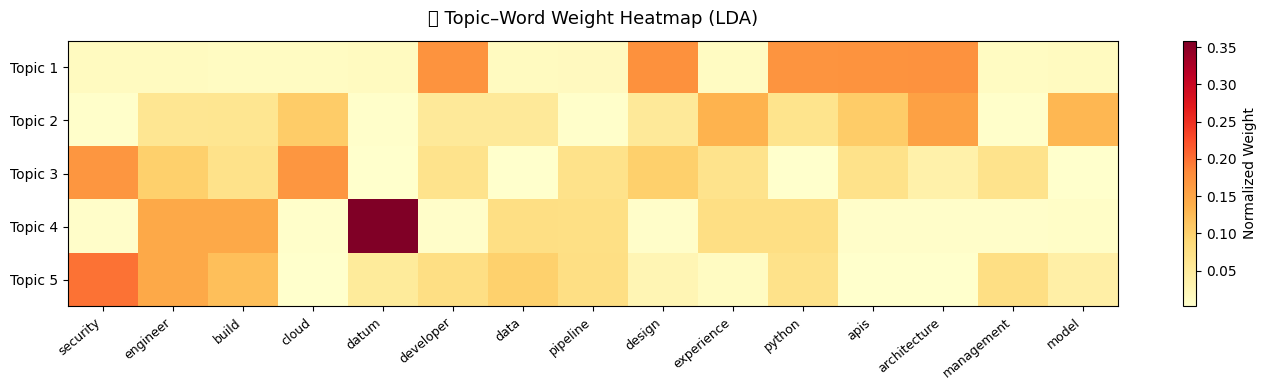

Darker = that word is more important to that topic


In [69]:
# ── Visualize: Topic-Word heatmap ──

N_WORDS_TO_SHOW = 15
topic_labels = [f"Topic {i+1}" for i in range(N_TOPICS)]

# Get top 15 words overall by total weight across topics
total_word_weights = lda.components_.sum(axis=0)
top_global_word_idx = total_word_weights.argsort()[:-N_WORDS_TO_SHOW - 1:-1]
top_global_words = [vocab[i] for i in top_global_word_idx]

# Build heatmap matrix
heatmap_data = lda.components_[:, top_global_word_idx]
# Normalize each topic row to show proportions
heatmap_norm = heatmap_data / heatmap_data.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(heatmap_norm, aspect='auto', cmap='YlOrRd')

ax.set_xticks(range(N_WORDS_TO_SHOW))
ax.set_xticklabels(top_global_words, rotation=40, ha='right', fontsize=9)
ax.set_yticks(range(N_TOPICS))
ax.set_yticklabels(topic_labels, fontsize=10)
ax.set_title("🔥 Topic–Word Weight Heatmap (LDA)", fontsize=13, pad=12)
plt.colorbar(im, ax=ax, label="Normalized Weight")
plt.tight_layout()
plt.savefig('/content/lda_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Darker = that word is more important to that topic")

In [70]:
# ── Document-Topic Distribution ──
# For each job posting, what % is each topic?

doc_topic_matrix = lda.transform(dtm)  # shape: (25, 5)

print("📄 Document–Topic Proportions (first 10 postings)\n")
print(f"{'Posting':<12} {'T1':>7} {'T2':>7} {'T3':>7} {'T4':>7} {'T5':>7}  {'Dominant':>14}  True Label")
print("-" * 85)

for i in range(10):
    proportions = doc_topic_matrix[i]
    dominant = f"Topic {np.argmax(proportions) + 1}"
    prop_str = "  ".join([f"{p:.2f}" for p in proportions])
    print(f"  Posting {i+1:<3}  {prop_str}  {dominant:>14}  {TRUE_LABELS[i]}")

📄 Document–Topic Proportions (first 10 postings)

Posting           T1      T2      T3      T4      T5        Dominant  True Label
-------------------------------------------------------------------------------------
  Posting 1    0.00  0.98  0.00  0.00  0.00         Topic 2  Data Science
  Posting 2    0.01  0.64  0.01  0.01  0.35         Topic 2  Data Science
  Posting 3    0.01  0.97  0.01  0.01  0.01         Topic 2  Data Science
  Posting 4    0.01  0.01  0.01  0.97  0.01         Topic 4  Data Science
  Posting 5    0.01  0.97  0.01  0.01  0.01         Topic 2  Data Science
  Posting 6    0.00  0.00  0.98  0.00  0.00         Topic 3  Web Development
  Posting 7    0.01  0.01  0.96  0.01  0.01         Topic 3  Web Development
  Posting 8    0.97  0.01  0.01  0.01  0.01         Topic 1  Web Development
  Posting 9    0.01  0.95  0.01  0.01  0.01         Topic 2  Web Development
  Posting 10   0.01  0.01  0.97  0.01  0.01         Topic 3  Web Development


---
## 3.5 — Choosing the Right Number of Topics (k)

> One of the hardest parts of topic modeling: **how many topics should we ask for?**

We use **perplexity** (lower = better fit) and **coherence** (higher = more interpretable topics) to guide the choice.

  k= 2  perplexity=155.6
  k= 3  perplexity=174.5
  k= 4  perplexity=200.7
  k= 5  perplexity=214.6
  k= 6  perplexity=255.6
  k= 7  perplexity=256.9
  k= 8  perplexity=328.6
  k=10  perplexity=435.6


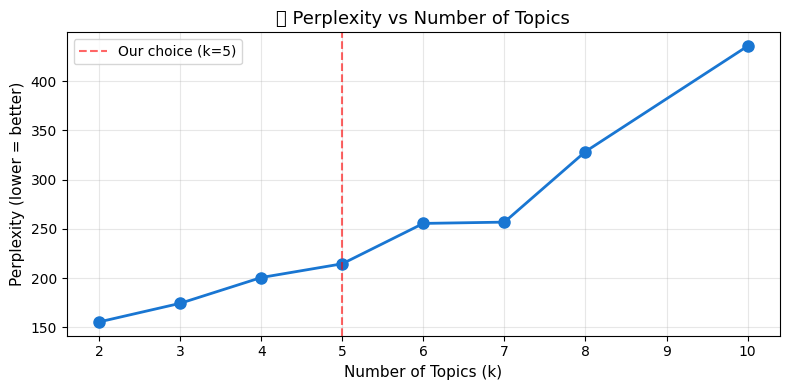


💡 Look for the 'elbow' — where adding more topics stops helping much.


In [72]:
# ── Perplexity vs Number of Topics ──
# Perplexity measures how well the model predicts unseen documents.
# It tends to decrease as k increases — so look for the 'elbow'.

k_values = [2, 3, 4, 5, 6, 7, 8, 10]
perplexities = []

for k in k_values:
    lda_k = LatentDirichletAllocation(
        n_components=k, max_iter=15,
        learning_method='online', random_state=42
    )
    lda_k.fit(dtm)
    perplexities.append(lda_k.perplexity(dtm))
    print(f"  k={k:>2}  perplexity={lda_k.perplexity(dtm):.1f}")

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_values, perplexities, marker='o', color='#1976D2', linewidth=2, markersize=8)
ax.axvline(x=5, color='red', linestyle='--', alpha=0.6, label='Our choice (k=5)')
ax.set_xlabel("Number of Topics (k)", fontsize=11)
ax.set_ylabel("Perplexity (lower = better)", fontsize=11)
ax.set_title("📉 Perplexity vs Number of Topics", fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/perplexity_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 Look for the 'elbow' — where adding more topics stops helping much.")

---
## 3.6 — NMF: Non-Negative Matrix Factorization

> **NMF** takes a different mathematical approach: it factorizes the TF-IDF matrix into two non-negative matrices — one for topics and one for document weights.

**NMF vs LDA:**
- NMF uses **TF-IDF** (word importance) → LDA uses raw **word counts**
- NMF is **deterministic** (same result every run) → LDA has randomness
- NMF topics tend to be **crisper** and easier to interpret
- LDA has a proper **probabilistic** foundation (can give uncertainty)

In [73]:
# NMF needs TF-IDF (not raw counts)
tfidf_vectorizer = TfidfVectorizer(
    max_df=0.90,
    min_df=2,
    max_features=300,
    ngram_range=(1, 2),
    stop_words='english'
)
tfidf_matrix = tfidf_vectorizer.fit_transform(processed_docs)
tfidf_vocab  = tfidf_vectorizer.get_feature_names_out()

# Train NMF
nmf = NMF(
    n_components=N_TOPICS,
    random_state=42,
    max_iter=500
)
nmf.fit(tfidf_matrix)

display_topics(nmf, tfidf_vocab, n_top_words=10, title="NMF — Job Postings Topics")


  NMF — Job Postings Topics

  📌 Topic 1:
     incident | response | incident response | analysis | analyst | detection | threat | management | security | tool

  📌 Topic 2:
     datum | data | stream | dashboard | business | sql | build | time | engineer apache | apache

  📌 Topic 3:
     developer | apis | react | user | responsive | native | strong | high | design | css javascript

  📌 Topic 4:
     learn | model | nlp | experience | machine | scikit learn | scikit | machine learn | deep | deploy

  📌 Topic 5:
     cloud | security | cloud security | aw | iam | compliance | architect | threat modeling | security engineer | review


In [74]:
# ── Side-by-side comparison: LDA vs NMF top words ──

def get_top_words(model, feature_names, n=8):
    topics = []
    for topic in model.components_:
        top_idx = topic.argsort()[:-n - 1:-1]
        topics.append([feature_names[i] for i in top_idx])
    return topics

lda_topics = get_top_words(lda, vocab)
nmf_topics = get_top_words(nmf, tfidf_vocab)

print("⚖️  LDA vs NMF — Top Words per Topic\n")
print(f"{'Topic':<8} {'LDA Top Words':<50} NMF Top Words")
print("-" * 110)
for i in range(N_TOPICS):
    lda_str = ", ".join(lda_topics[i])
    nmf_str = ", ".join(nmf_topics[i])
    print(f"  {i+1}     {lda_str:<50} {nmf_str}")

⚖️  LDA vs NMF — Top Words per Topic

Topic    LDA Top Words                                      NMF Top Words
--------------------------------------------------------------------------------------------------------------
  1     clean, postgresql, design, rest, redis, architecture, rest apis, code incident, response, incident response, analysis, analyst, detection, threat, management
  2     native, learn, architecture, expertise, nlp, experience, model, cloud datum, data, stream, dashboard, business, sql, build, time
  3     security, cloud, high, cloud security, user, engineer, design, aw developer, apis, react, user, responsive, native, strong, high
  4     datum, stream, engineer, build, dashboard, spark, time, create learn, model, nlp, experience, machine, scikit learn, scikit, machine learn
  5     security, engineer, build, data, threat, management, pipeline, incident cloud, security, cloud security, aw, iam, compliance, architect, threat modeling


---
## 3.7 — Interactive Visualization with pyLDAvis

> **pyLDAvis** is the standard tool for exploring LDA topics interactively.  
> - Each **bubble** = one topic. Bigger bubble = more prevalent topic.  
> - **Distance between bubbles** = how different the topics are.  
> - Click a topic to see its most relevant words on the right.

In [75]:
import pyLDAvis
import pyLDAvis.lda_model as pyLDAvis_sk

pyLDAvis.enable_notebook()

panel = pyLDAvis_sk.prepare(lda, dtm, count_vectorizer, mds='tsne', sort_topics=False)
pyLDAvis.display(panel)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### 🧭 How to Read the pyLDAvis Plot

- **Left panel:** Topic bubbles in 2D space (t-SNE projection).
  - Bubbles far apart → very different topics ✅
  - Overlapping bubbles → topics are too similar (try reducing k)
- **Right panel:** Top words for selected topic.
  - **Red bar** = word frequency within this topic
  - **Blue bar** = overall word frequency in corpus
  - **λ (lambda) slider**: Move left for more topic-specific words; move right for more frequent words. λ ≈ 0.6 usually gives the most interpretable results.

---
## 3.8 — Applying Topic Modeling to Product Reviews

Now let's apply the same technique to customer reviews — discovering complaint themes automatically.

In [76]:
# Larger set of product reviews (e-commerce context)
REVIEW_CORPUS = [
    # Delivery / Shipping
    "Package arrived 3 days late. The delivery was extremely slow and tracking information was wrong.",
    "Fast shipping! Got the item within 24 hours. Packaging was excellent and secure.",
    "Delivery was delayed by a week without any notification. Very poor logistics experience.",
    "Same day delivery worked perfectly. The courier was polite and on time.",
    "Wrong item delivered. I ordered a red shirt but received a blue one. Frustrating!",

    # Product Quality
    "Product quality is terrible. It broke after just two uses. Complete waste of money.",
    "Build quality is excellent. Feels premium and sturdy. Worth every rupee.",
    "The material looks cheap and doesn't match the product images shown online.",
    "Outstanding quality for the price. Very durable and well made.",
    "Product stopped working after one month. Clearly a manufacturing defect.",

    # Customer Service
    "Customer support was absolutely useless. Waited 45 minutes on hold with no resolution.",
    "Excellent service! The support team resolved my issue in under 10 minutes.",
    "Refund process took 15 days. Too slow and very poor communication from the team.",
    "Customer care agent was rude and unhelpful. Will never shop here again.",
    "The return process was seamless and the refund was instant. Very happy!",

    # Price / Value
    "Way overpriced for what you get. Similar products are available at half the price.",
    "Great value for money. Cannot believe the quality at this price point!",
    "The discount on the sale was misleading. Original price was inflated to show fake savings.",
    "Absolutely worth the price. Best investment I made this year.",
    "Too expensive. The features don't justify this premium pricing.",

    # App / Website Experience
    "The app is very buggy and crashes frequently during checkout. Very frustrating.",
    "Great user interface on the website. Very easy to search, filter, and place orders.",
    "Payment failed three times despite money being deducted from my account.",
    "The mobile app is smooth and fast. Checkout process is clean and intuitive.",
    "Website is extremely slow and the search results are often irrelevant.",

    # Battery and Performance (Electronics)
    "Battery drains so fast! Barely lasts 4 hours with normal usage. Very disappointing.",
    "Amazing battery life. Used it for 3 days on a single charge during travel.",
    "The phone heats up severely during gaming. Thermal management is very poor.",
    "Performance is buttery smooth even after 2 years of use. Excellent optimization.",
    "Processor lags when multitasking. Cannot handle more than 5 apps simultaneously.",
]

# Preprocess
processed_reviews = [preprocess_for_topics(r) for r in REVIEW_CORPUS]

# Build DTM
review_vec = CountVectorizer(max_df=0.85, min_df=2, max_features=200, ngram_range=(1,2))
review_dtm = review_vec.fit_transform(processed_reviews)
review_vocab = review_vec.get_feature_names_out()

print(f"✅ Review corpus: {review_dtm.shape[0]} reviews × {review_dtm.shape[1]} terms")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

✅ Review corpus: 30 reviews × 38 terms


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [77]:
# Train LDA on reviews — we expect ~6 themes
lda_reviews = LatentDirichletAllocation(
    n_components=6,
    max_iter=30,
    random_state=42,
    doc_topic_prior=0.1,
    topic_word_prior=0.01
)
lda_reviews.fit(review_dtm)

# Topic names (we'll interpret and name them after seeing the words)
TOPIC_NAMES = [
    "🚚 Delivery & Shipping",
    "🏭 Product Quality",
    "🎧 Customer Service",
    "💰 Price & Value",
    "📱 App/Web Experience",
    "🔋 Electronics Performance"
]

print("\n📋 Review Topics Discovered by LDA:\n")
for topic_idx, topic in enumerate(lda_reviews.components_):
    top_idx = topic.argsort()[:-11:-1]
    top_words = [review_vocab[i] for i in top_idx]
    print(f"  {TOPIC_NAMES[topic_idx] if topic_idx < len(TOPIC_NAMES) else f'Topic {topic_idx+1}'}")
    print(f"    Words: {' | '.join(top_words)}\n")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


📋 Review Topics Discovered by LDA:

  🚚 Delivery & Shipping
    Words: customer | support | minute | absolutely | year | wrong | use | website | work | worth

  🏭 Product Quality
    Words: slow | website | extremely slow | extremely | search | premium | delivery | day | wrong | order

  🎧 Customer Service
    Words: price | quality | money | quality price | time | delivery | day | work | great | use

  💰 Price & Value
    Words: price | excellent | item | frustrating | year | worth | order | hour | wrong | fast

  📱 App/Web Experience
    Words: product | fast | battery | use | hour | work | quality | money | day | premium

  🔋 Electronics Performance
    Words: process | poor | app | refund | smooth | checkout | team | day | year | use



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

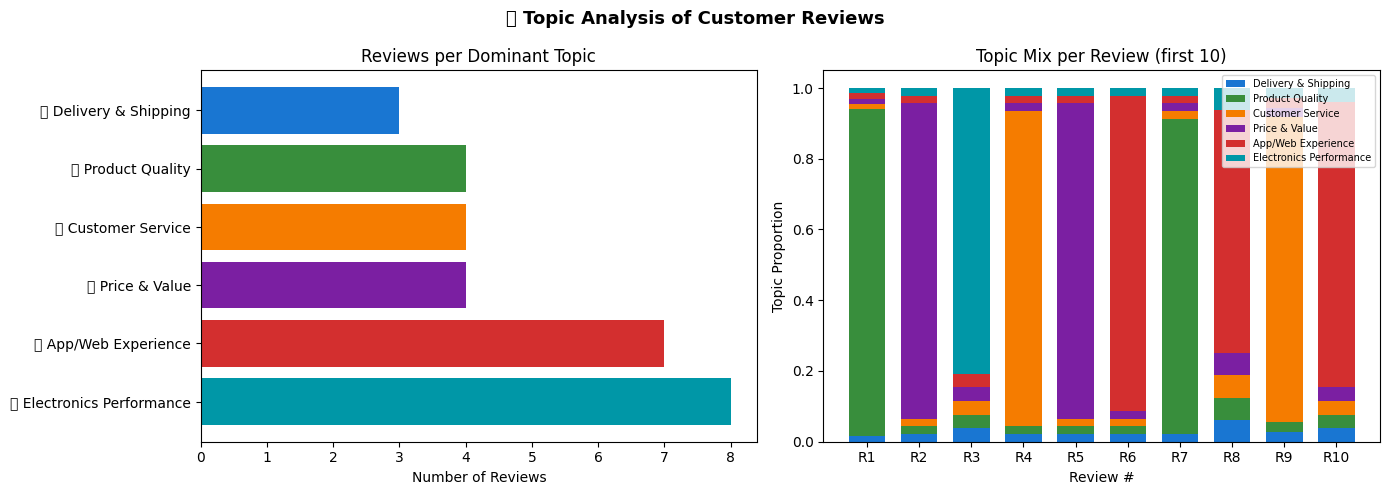

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [79]:
# ── Visualize: Topic distribution across reviews ──

doc_topics_reviews = lda_reviews.transform(review_dtm)
dominant_topics = doc_topics_reviews.argmax(axis=1)

# Count reviews per dominant topic
topic_counts = Counter(dominant_topics)
sorted_topics = sorted(topic_counts.items())

labels = [TOPIC_NAMES[t] if t < len(TOPIC_NAMES) else f"Topic {t+1}" for t, _ in sorted_topics]
counts = [c for _, c in sorted_topics]
colors_bar = ['#1976D2','#388E3C','#F57C00','#7B1FA2','#D32F2F','#0097A7']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("📊 Topic Analysis of Customer Reviews", fontsize=13, fontweight='bold')

# Bar chart: review count per topic
axes[0].barh(labels, counts, color=colors_bar[:len(labels)])
axes[0].set_xlabel("Number of Reviews")
axes[0].set_title("Reviews per Dominant Topic")
axes[0].invert_yaxis()

# Stacked bar: topic mix across 30 reviews (sample of 10)
sample_size = 10
bottom = np.zeros(sample_size)
for t_idx in range(6):
    vals = doc_topics_reviews[:sample_size, t_idx]
    color = colors_bar[t_idx % len(colors_bar)]
    label = TOPIC_NAMES[t_idx] if t_idx < len(TOPIC_NAMES) else f"T{t_idx+1}"
    axes[1].bar(range(sample_size), vals, bottom=bottom, color=color,
                label=label.split(' ', 1)[-1], width=0.7)
    bottom += vals

axes[1].set_xlabel("Review #")
axes[1].set_ylabel("Topic Proportion")
axes[1].set_title("Topic Mix per Review (first 10)")
axes[1].legend(loc='upper right', fontsize=7, framealpha=0.8)
axes[1].set_xticks(range(sample_size))
axes[1].set_xticklabels([f"R{i+1}" for i in range(sample_size)])

plt.tight_layout()
plt.savefig('/content/review_topics.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3.9 — Topic Modeling on Resumes: Skill Cluster Discovery

Topic modeling on a resume corpus can automatically discover **skill clusters** — which skills tend to appear together — without any manual tagging.

In [80]:
# A corpus of 15 short candidate skill summaries
CANDIDATE_SKILLS = [
    "Python pandas numpy scikit-learn tensorflow deep learning neural networks classification",
    "SQL MySQL PostgreSQL database design query optimization indexing stored procedures",
    "React JavaScript HTML CSS Node.js REST API frontend development user interface",
    "Docker Kubernetes AWS CI/CD Jenkins Terraform infrastructure deployment automation",
    "Python machine learning data analysis visualization matplotlib seaborn statistics",
    "Java Spring Boot microservices REST API backend development Maven JUnit testing",
    "Spark Kafka Hadoop ETL pipeline data warehouse BigQuery Airflow data engineering",
    "PyTorch BERT transformers NLP text classification sentiment analysis hugging face",
    "Linux bash scripting network security firewall penetration testing SIEM vulnerability",
    "Angular TypeScript Bootstrap frontend web development responsive design Figma UX",
    "Python Flask Django REST API backend database SQLAlchemy authentication deployment",
    "AWS GCP cloud architecture serverless Lambda DynamoDB S3 cost optimization",
    "Tableau Power BI Excel data visualization dashboards business intelligence reporting",
    "TensorFlow Keras computer vision CNN image classification object detection OpenCV",
    "Spark Scala data pipeline streaming processing Kafka distributed computing optimization",
]

# Build DTM
skill_vec = CountVectorizer(max_df=0.95, min_df=1, max_features=100)
skill_dtm = skill_vec.fit_transform(CANDIDATE_SKILLS)
skill_vocab = skill_vec.get_feature_names_out()

# Train LDA with 5 topics
lda_skills = LatentDirichletAllocation(n_components=5, max_iter=50, random_state=42)
lda_skills.fit(skill_dtm)

SKILL_CLUSTER_NAMES = [
    "🤖 ML / Data Science",
    "🌐 Web Development",
    "☁️  Cloud / DevOps",
    "🔧 Data Engineering",
    "🔐 Security / Backend"
]

print("🛠️ Skill Clusters Discovered by LDA on Resume Corpus:\n")
for t_idx, topic in enumerate(lda_skills.components_):
    top_words = [skill_vocab[i] for i in topic.argsort()[:-9:-1]]
    name = SKILL_CLUSTER_NAMES[t_idx] if t_idx < len(SKILL_CLUSTER_NAMES) else f"Cluster {t_idx+1}"
    print(f"  {name}")
    print(f"    → {' | '.join(top_words)}\n")

# Assign each candidate to their dominant skill cluster
candidate_topics = lda_skills.transform(skill_dtm)
print("\n👤 Candidate → Dominant Skill Cluster:")
for i, (profile, topic_dist) in enumerate(zip(CANDIDATE_SKILLS, candidate_topics)):
    dom = topic_dist.argmax()
    name = SKILL_CLUSTER_NAMES[dom] if dom < len(SKILL_CLUSTER_NAMES) else f"Cluster {dom+1}"
    print(f"  Candidate {i+1:>2}: {name:<30} [{profile[:50]}...]")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

🛠️ Skill Clusters Discovered by LDA on Resume Corpus:

  🤖 ML / Data Science
    → python | classification | learning | tensorflow | networks | neural | pandas | numpy

  🌐 Web Development
    → visualization | backend | database | reporting | excel | bi | business | dashboards

  ☁️  Cloud / DevOps
    → analysis | aws | design | deployment | docker | infrastructure | jenkins | kubernetes

  🔧 Data Engineering
    → data | optimization | pipeline | spark | kafka | hadoop | engineering | bigquery

  🔐 Security / Backend
    → development | rest | api | testing | frontend | javascript | html | interface


👤 Candidate → Dominant Skill Cluster:
  Candidate  1: 🤖 ML / Data Science            [Python pandas numpy scikit-learn tensorflow deep l...]
  Candidate  2: ☁️  Cloud / DevOps             [SQL MySQL PostgreSQL database design query optimiz...]
  Candidate  3: 🔐 Security / Backend           [React JavaScript HTML CSS Node.js REST API fronten...]
  Candidate  4: ☁️  Cloud / DevOps       

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

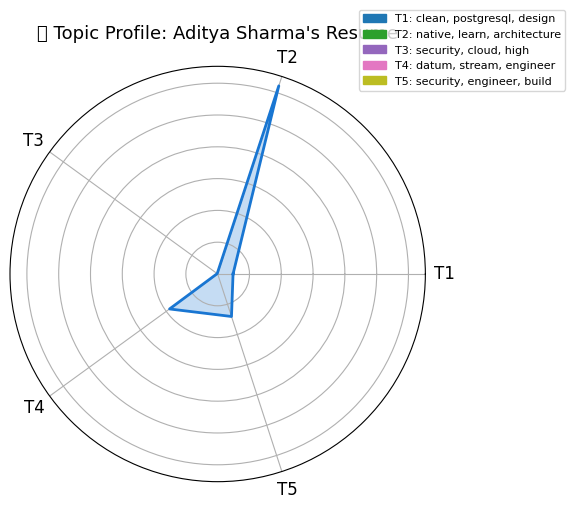


🧭 Resume Topic Distribution:
  Topic 1  0.048  █
  Topic 2  0.622  ████████████████████████
  Topic 3  0.002  
  Topic 4  0.187  ███████
  Topic 5  0.141  █████


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [82]:
# ── Radar chart: Topic profile of our full sample resume ──
# This shows WHAT topics Aditya's resume covers and in what proportion

import matplotlib.patches as mpatches

# Classify the sample resume from Section 1
resume_processed = preprocess_for_topics(SAMPLE_RESUME)
resume_dtm_transformed = count_vectorizer.transform([resume_processed])
resume_topic_dist = lda.transform(resume_dtm_transformed)[0]

# Radar chart
topic_names_short = [f"T{i+1}" for i in range(N_TOPICS)]
angles = np.linspace(0, 2 * np.pi, N_TOPICS, endpoint=False).tolist()
values = resume_topic_dist.tolist()

# Close the polygon
angles += angles[:1]
values += values[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.fill(angles, values, color='#1976D2', alpha=0.25)
ax.plot(angles, values, color='#1976D2', linewidth=2)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(topic_names_short, size=12)
ax.set_yticklabels([])
ax.set_title("📡 Topic Profile: Aditya Sharma's Resume", size=13, pad=20)

# Legend showing LDA topic top words
lda_top = get_top_words(lda, vocab, n=4)
legend_labels = [f"T{i+1}: {', '.join(lda_top[i][:3])}" for i in range(N_TOPICS)]
patches = [mpatches.Patch(color=cm.tab10(i/N_TOPICS), label=legend_labels[i]) for i in range(N_TOPICS)]
ax.legend(handles=patches, loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=8)

plt.tight_layout()
plt.savefig('/content/radar_topic_profile.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🧭 Resume Topic Distribution:")
for i, score in enumerate(resume_topic_dist):
    bar = '█' * int(score * 40)
    print(f"  Topic {i+1}  {score:.3f}  {bar}")

---
## 3.10 — Topic Modeling Best Practices

A quick summary of what to watch out for in practice:

In [83]:
# ── Demonstration: What happens when preprocessing is bad ──

# Bad DTM: no stopword removal, no lemmatization
bad_vec = CountVectorizer(max_features=20)
bad_dtm = bad_vec.fit_transform(JOB_POSTINGS)  # raw text, no preprocessing
lda_bad = LatentDirichletAllocation(n_components=3, max_iter=10, random_state=42)
lda_bad.fit(bad_dtm)

# Good DTM: preprocessed text
good_vec = CountVectorizer(max_features=20)
good_dtm = good_vec.fit_transform(processed_docs)
lda_good = LatentDirichletAllocation(n_components=3, max_iter=10, random_state=42)
lda_good.fit(good_dtm)

print("❌ Topics WITHOUT preprocessing (dominated by stopwords):")
for t_idx, topic in enumerate(lda_bad.components_):
    words = [bad_vec.get_feature_names_out()[i] for i in topic.argsort()[:-8:-1]]
    print(f"   Topic {t_idx+1}: {words}")

print("\n✅ Topics WITH preprocessing (meaningful words):")
for t_idx, topic in enumerate(lda_good.components_):
    words = [good_vec.get_feature_names_out()[i] for i in topic.argsort()[:-8:-1]]
    print(f"   Topic {t_idx+1}: {words}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

❌ Topics WITHOUT preprocessing (dominated by stopwords):
   Topic 1: ['and', 'security', 'cloud', 'management', 'in', 'engineer', 'expertise']
   Topic 2: ['and', 'data', 'engineer', 'build', 'pipelines', 'with', 'python']
   Topic 3: ['and', 'with', 'developer', 'apis', 'to', 'in', 'build']

✅ Topics WITH preprocessing (meaningful words):
   Topic 1: ['security', 'cloud', 'management', 'threat', 'design', 'developer', 'engineer']
   Topic 2: ['engineer', 'build', 'data', 'pipeline', 'learn', 'model', 'expertise']
   Topic 3: ['datum', 'apis', 'developer', 'experience', 'build', 'python', 'architecture']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [85]:
# ── Summary: LDA vs NMF — when to use which ──

comparison_table = {
    "Input": ["Count matrix (DTM)", "TF-IDF matrix"],
    "Math": ["Probabilistic (Bayesian)", "Matrix factorization"],
    "Randomness": ["Yes (random_state needed)", "Deterministic"],
    "Topic sharpness": ["Softer (overlapping)", "Crisper (focused)"],
    "Interpretability": ["Moderate", "Often better"],
    "Speed": ["Slower", "Faster"],
    "Best for": ["Large corpora, social media, news", "Short docs, product reviews, resumes"],
}

print(f"{'Criterion':<20} {'LDA':<35} NMF")
print("-" * 80)
for criterion, (lda_val, nmf_val) in comparison_table.items():
    print(f"  {criterion:<18} {lda_val:<35} {nmf_val}")

print("\n💡 Rule of thumb: Try BOTH and pick the one whose topics make more intuitive sense.")

Criterion            LDA                                 NMF
--------------------------------------------------------------------------------
  Input              Count matrix (DTM)                  TF-IDF matrix
  Math               Probabilistic (Bayesian)            Matrix factorization
  Randomness         Yes (random_state needed)           Deterministic
  Topic sharpness    Softer (overlapping)                Crisper (focused)
  Interpretability   Moderate                            Often better
  Speed              Slower                              Faster
  Best for           Large corpora, social media, news   Short docs, product reviews, resumes

💡 Rule of thumb: Try BOTH and pick the one whose topics make more intuitive sense.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

---
### ✏️ Exercise 3 (5 min)
The corpus below contains a mix of topics. Without running any code, **guess what themes** you'd expect LDA to find. Then run it and compare.

Try changing `n_components` between 2, 3, and 4 — at which value do the topics look most distinct and meaningful to you?

In [86]:
MIXED_CORPUS = [
    "Python machine learning deep learning neural network classification regression",
    "cricket batting bowling match score wicket IPL stadium player century",
    "SQL database query join index transaction backup PostgreSQL optimization",
    "Virat Kohli batting record test match runs century cricket team India",
    "JavaScript React frontend component hook state API fetch JSON",
    "food recipe cooking ingredients vegetarian spice curry masala Indian kitchen",
    "Rohit Sharma opening batsman IPL Mumbai Indians cricket captain",
    "machine learning model training accuracy validation overfitting regularization",
    "HTML CSS border margin padding grid flexbox responsive mobile design",
    "biryani dosa idli sambar tandoori naan paneer tikka chicken masala",
]

# ── Your guess: what 3 topics do you expect? Write them here ──
# Topic 1: ...
# Topic 2: ...
# Topic 3: ...

# ── Now run LDA and check ──
n_components = 3  # ← try changing this to 2, 3, 4

mixed_vec = CountVectorizer(min_df=1, max_features=80)
mixed_dtm = mixed_vec.fit_transform(MIXED_CORPUS)
lda_mixed = LatentDirichletAllocation(n_components=n_components, max_iter=30, random_state=42)
lda_mixed.fit(mixed_dtm)

print(f"\nTopics discovered (k={n_components}):")
for t_idx, topic in enumerate(lda_mixed.components_):
    words = [mixed_vec.get_feature_names_out()[i] for i in topic.argsort()[:-8:-1]]
    print(f"  Topic {t_idx+1}: {words}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


Topics discovered (k=3):
  Topic 1: ['learning', 'machine', 'deep', 'classification', 'python', 'regression', 'network']
  Topic 2: ['cricket', 'batting', 'match', 'century', 'ipl', 'team', 'runs']
  Topic 3: ['masala', 'tikka', 'sambar', 'tandoori', 'idli', 'paneer', 'naan']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

---
# 🏆 FINAL CHALLENGE (10 min)

**Choose ONE of the following tasks and implement it:**

### 🅰️ Resume Challenge
A company wants to hire a **Full Stack Developer**. They require: React, Node.js, MongoDB, REST APIs, JavaScript, Git, AWS.  
Write a sample resume for this role and score it against the job description using our matcher. Aim for a score > 0.20.

### 🅱️ Sentiment Challenge
Copy 5 real reviews of any product from Flipkart/Amazon (search for reviews online).  
Run them through VADER + TextBlob. Compare results. Find at least one case where the two models disagree.

### 🅲️ Extension: Build a Mini ATS Filter
Given multiple resumes, rank them for a job description by their cosine similarity score. The function should return a ranked list of candidates.

In [87]:
# ── CHALLENGE WORKSPACE ──────────────────────────────────
#
# Use this cell for your challenge solution.
#
# Hint for Challenge C: multi_resume_ranker(resumes_list, job_description)
#   → Use the vectorizer2 and cosine_similarity from Section 1.5
#   → Return sorted list of (candidate_name, score) tuples
#
# ─────────────────────────────────────────────────────────

# Your code here 👇


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

---
# 📚 Session Summary

## What We Built

| Component | Technique | Tool Used |
|-----------|-----------|----------|
| Name & Contact Extraction | NER + Regex | spaCy + re |
| Skills Extraction | Vocabulary Matching | Python dict |
| Domain Classification | TF-IDF + Cosine Similarity | Scikit-learn |
| JD-Resume Matching | TF-IDF bigrams | Scikit-learn |
| Sentiment Analysis (rule-based) | Lexicon + heuristics | VADER |
| Sentiment Analysis (ML) | Naive Bayes corpus | TextBlob |
| Sentiment Analysis (deep learning) | Transformer fine-tuning | DistilBERT |
| Aspect-Based Sentiment | Pattern matching + VADER | spaCy + VADER |
| Emotion Detection | Transformer fine-tuning | DistilRoBERTa |
| Review Analytics | TF-IDF + visualization | Matplotlib |
| Topic Discovery (LDA) | Latent Dirichlet Allocation | Scikit-learn + pyLDAvis |
| Topic Discovery (NMF) | Non-negative Matrix Factorization | Scikit-learn |

## Key Takeaways

1. **Resume mining = NER + section detection + keyword matching.** Real ATS systems do exactly this at scale.

2. **Rule-based models (VADER, TextBlob)** are fast, explainable, and require no training data — but struggle with sarcasm and complex negation.

3. **Transformer models (BERT, DistilBERT)** understand context deeply — they're the gold standard but require more compute.

4. **Aspect-based analysis** is the most commercially valuable form — it tells a product team *specifically what to fix*.

5. **Subjectivity score** (TextBlob) helps separate facts from opinions — important when building trustworthy review systems.

---

## 🔗 Where to Go From Here

- **Resume Mining**: Try [pyresparser](https://github.com/OmkarPathak/pyresparser) — a full open-source resume parser
- **Custom NER**: Train your own entity recognizer on spaCy with annotated resume data
- **Sentiment**: Explore [cardiffnlp/twitter-roberta-base-sentiment](https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment) on Hugging Face
- **ABSA**: Try the [PyABSA](https://github.com/yangheng95/PyABSA) library — state-of-the-art aspect-based analysis
- **Topic Modeling**: Try [BERTopic](https://maartengr.github.io/BERTopic/) — transformer-based topic modeling with automatic labeling
- **Topic Coherence**: Use  CoherenceModel for rigorous k selection
- **Production**: Wrap any of these pipelines as a **FastAPI endpoint** or **Streamlit app**

---
*CO-4 NLP Workshop | All code is yours to keep and extend!*